<div style="background: linear-gradient(90deg, #6dd5ed, #2193b0); padding: 30px; border-radius: 15px; box-shadow: 0 4px 12px rgba(44, 62, 80, 0.15); text-align: center;">
    <h1 style="color: #fff; font-size: 2.8em; font-weight: bold; letter-spacing: 2px; margin-bottom: 1;">
        Predict Introvert from Extrovert
    </h1>
    <p style="color: #f7f7f7; font-size: 1.2em; margin-top: 10px;">
        Discover personality traits with data-driven insights
    </p>
</div>

<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8" />
  <meta name="viewport" content="width=device-width, initial-scale=1.0"/>
  <title></title>
  <style>
    body {
      font-family: 'Segoe UI', sans-serif;
      background-color:rgb(167, 233, 213);
      color: #222;
      margin: 0;
      padding: 0;
      text-align: left;
    }

    h1 {
      font-size: 2.5em;
      margin-top: 80px;
      padding: 20px;
      background-color:rgb(229, 212, 212);
      border: 1px solid #ddd;
      border-radius: 8px;
      display: inline-block;
      color:rgb(49, 108, 167);
    }

    h1 span {
      display: block;
      font-size: 1em;
      color: #555;
      margin-top: 8px;
    }

    .author-container {
      display: flex;
      justify-content: center;
      align-items: center;
      flex-wrap: wrap;
      gap: 20px;
      margin: 30px auto;
      padding: 20px;
      max-width: 700px;
      background-color: #fff;
      border: 1px solid #ddd;
      border-radius: 8px;
    }

    .author-container a {
      text-decoration: none;
    }

    .author-container img {
      border-radius: 6px;
      padding: 6px;
      background-color:rgb(234, 234, 234);
    }

    .author-container a span {
      display: block;
      margin-top: 6px;
      font-size: 0.95em;
      color: #333;
    }
  </style>
</head>
<body>

<h1 style="
  font-family: 'Segoe UI', sans-serif;
  font-weight: bold;
  font-style: italic;
  color:rgb(49, 108, 167);
  -webkit-font-smoothing: antialiased;
  text-shadow: 0 1px 1px rgba(218, 55, 55, 0.94);
">
  👨‍🏫 Author: Muhammad Mohsin Farooq
</h1>


  <div class="author-container">
    <a href="https://github.com/MOHSIN184" target="_blank">
      <img src="https://img.shields.io/badge/GitHub-Profile-181717?style=for-the-badge&logo=github" alt="GitHub">
    </a>
    <a href="https://www.kaggle.com/mmohsinfarooqhussain" target="_blank">
      <img src="https://img.shields.io/badge/Kaggle-Profile-20BEFF?style=for-the-badge&logo=kaggle" alt="Kaggle">
    </a>
    <a href="http://www.linkedin.com/in/m-mohsin-farooq-hussain-962a9a323" target="_blank">
      <img src="https://img.shields.io/badge/LinkedIn-Profile-0077B5?style=for-the-badge&logo=linkedin" alt="LinkedIn">
    </a>
  </div>

</body>
</html>


## 📑 Table of Contents

🔹 [1. Introduction](#Introduction)  
　　About the Dataset.

🔹 [2. Import Libraries](#Import-Libraries)  
　　Load required libraries and packages.

🔹 [3. Load Data](#Load-Data)  
　　Import datasets for training and testing.

🔹 [4. EDA](#eda)  
　　Explore data distributions and relationships.

🔹 [5. Plot Data](#plot-data)  
　　I created a data plotting system using ipywidgets, so it does not work in the display environment.<br>
  To use it, copy the file and run it in the runtime environment.

🔹 [6. Preprocessing](#preprocessing)  
　　Clean, transform, and prepare data for modeling.

🔹 [7. Models](#models)  
　　Model and forecast with xgboost, lightgbm, catboost, and perform hyper parameter optimization.

🔹 [8. Display Result](#display-result)  
　　Show predictions and performance metrics.

🔹 [9. Submission](#submission)  
　　Format and export results for Kaggle submission.





# Introduction

### 🎯 Problem Objective
This project aims to explore and model human behavior based on personality types — **extroverts** and **introverts** — using survey data.  
Our goal is to predict personality classification using behavioral and lifestyle indicators such as sleep patterns, gaming habits, and communication preferences. This type of analysis can be helpful in personalized recommendations, HR screening, or mental health support tools.

> 🧠 **Goal:** Predict whether a person is an extrovert or introvert based on their responses to behavioral questions.

---

### 📊 Data Characteristics

- The dataset contains answers to a series of survey questions related to:
  - **Lifestyle habits:** like sleep timing, online gaming frequency
  - **Communication preferences:** phone call duration, messaging behavior
  - **Mood and social interactions**


### 🔑 Key Columns Overview

| Column Name                   | Description                                                                 |
|------------------------------|-----------------------------------------------------------------------------|
| `id`                         | Unique identifier for each individual record                                |
| `Time_spent_Alone`           | Number of hours spent alone per day                                        |
| `Stage_fear`                 | Whether the person has a fear of public speaking (`Yes`/`No`)              |
| `Social_event_attendance`    | Average number of social events attended per month                         |
| `Going_outside`              | Average number of days per week the person goes outside                    |
| `Drained_after_socializing` | Whether the person feels mentally drained after social interactions (`Yes`/`No`) |
| `Friends_circle_size`        | Number of close friends the person has                                     |
| `Post_frequency`             | Average number of social media posts per month                             |
| `Personality`                | Target variable: Personality type (`Introvert` or `Extrovert`)             |

# Import Libraries

In [102]:
# Core libraries

import pandas as pd
import numpy as np
import warnings

# Data visualization libraries

import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
# Setting display options

pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

# Load Data

In [103]:
# Load the Given Datasets

df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')
df_sample_submission = pd.read_csv('sample_submission.csv')

print(f'N_train = {len(df_train)}, N_test = {len(df_test)}')

# Displaying the first few rows of the datasets
print("Train Dataset:")
print(df_train.head())
print("\nTest Dataset:")
print(df_test.head())

N_train = 18524, N_test = 6175
Train Dataset:
   id  Time_spent_Alone Stage_fear  Social_event_attendance  Going_outside  \
0   0               0.0         No                      6.0            4.0   
1   1               1.0         No                      7.0            3.0   
2   2               6.0        Yes                      1.0            0.0   
3   3               3.0         No                      7.0            3.0   
4   4               1.0         No                      4.0            4.0   

  Drained_after_socializing  Friends_circle_size  Post_frequency Personality  
0                        No                 15.0             5.0   Extrovert  
1                        No                 10.0             8.0   Extrovert  
2                       NaN                  3.0             0.0   Introvert  
3                        No                 11.0             5.0   Extrovert  
4                        No                 13.0             NaN   Extrovert  

Test Datas

# EDA

### Key Insights

In [104]:
def explain_key_insights_train(df_train):
    """
    Summarizes key insights from the training dataset for personality prediction.

    Returns:
        insights (dict): Dictionary containing summary statistics and observations.
    """
    insights = {}

    # 1. Missing Values
    missing = df_train.isnull().sum()
    missing_percent = (missing / len(df_train)) * 100
    insights['missing_values'] = missing[missing > 0].to_dict()
    insights['missing_percent'] = missing_percent[missing_percent > 0].round(2).to_dict()

    # 2. Numeric Feature Summary
    numeric_cols = df_train.select_dtypes(include=['float64', 'int64']).columns
    numeric_summary = df_train[numeric_cols].describe().T
    insights['numeric_summary'] = numeric_summary[['mean', 'std', 'min', 'max']].to_dict()

    # 3. Categorical Feature Distribution
    categorical_cols = df_train.select_dtypes(include=['object']).columns
    cat_distributions = {}
    for col in categorical_cols:
        cat_distributions[col] = df_train[col].value_counts(dropna=False).to_dict()
    insights['categorical_distributions'] = cat_distributions

    # 4. Notable Observations
    insights['observations'] = [
        "Training set contains missing values in several features.",
        "Numeric features show a wide range of values.",
        "Categorical features distributions provide insight into class balance.",
        "Personality column is present and used as the target variable."
    ]

    return insights

def explain_key_insights_test(df_test):
    """
    Summarizes key insights from the test dataset for personality prediction.

    Returns:
        insights (dict): Dictionary containing summary statistics and observations.
    """
    insights = {}

    # 1. Missing Values
    missing = df_test.isnull().sum()
    missing_percent = (missing / len(df_test)) * 100
    insights['missing_values'] = missing[missing > 0].to_dict()
    insights['missing_percent'] = missing_percent[missing_percent > 0].round(2).to_dict()

    # 2. Numeric Feature Summary
    numeric_cols = df_test.select_dtypes(include=['float64', 'int64']).columns
    numeric_summary = df_test[numeric_cols].describe().T
    insights['numeric_summary'] = numeric_summary[['mean', 'std', 'min', 'max']].to_dict()

    # 3. Categorical Feature Distribution
    categorical_cols = df_test.select_dtypes(include=['object']).columns
    cat_distributions = {}
    for col in categorical_cols:
        cat_distributions[col] = df_test[col].value_counts(dropna=False).to_dict()
    insights['categorical_distributions'] = cat_distributions

    # 4. Notable Observations
    insights['observations'] = [
        "Test set contains missing values in several features.",
        "Numeric features show similar ranges as training set.",
        "Categorical features distributions can be compared with training set for consistency.",
        "Personality column is missing in test set (to be predicted)."
    ]

    return insights


In [105]:
from IPython.display import display, HTML

def insight_card(title, table_html):
  return f"""
  <div style="background: linear-gradient(90deg, #f8ffae, #43c6ac); margin-bottom:18px; padding:18px; border-radius:12px; box-shadow:0 2px 8px rgba(44,62,80,0.10);">
    <h3 style="color:#2d3e50; font-weight:bold; text-align:center; letter-spacing:1px;">{title}</h3>
    {table_html}
  </div>
  """

# For df_train
rows = df_train['Personality'].value_counts().reset_index().values.tolist()
personality_html = f"""
<table style="width:100%; border-collapse:collapse; font-size:1.08em;">
  <tr style="background:#ffb347; color:#fff;"></tr>
  <th colspan="2">Personality Distribution</th>
  </tr>
  {''.join([f"<tr style='background:#fffbe6;'><td>{r[0]}</td><td><span style='font-weight:bold; color:#ff5722;'>{r[1]}</span></td></tr>" for r in rows])}
</table>
"""

missing_rows = [(col, round(100 * df_train[col].isnull().sum() / len(df_train), 2)) for col in df_train.columns if df_train[col].isnull().sum() > 0]
missing_html = f"""
<table style="width:100%; border-collapse:collapse; font-size:1.08em;">
  <tr style="background:#43c6ac; color:#fff;">
  <th colspan="2">Missing Values (%)</th>
  </tr>
  {''.join([f"<tr style='background:#e0f7fa;'><td>{r[0]}</td><td><span style='font-weight:bold; color:#009688;'>{r[1]}</span></td></tr>" for r in missing_rows])}
</table>
"""

# Compute numeric_rows for df_train
numeric_cols = df_train.select_dtypes(include=['float64', 'int64']).columns
numeric_rows = [
  (
    col,
    round(df_train[col].mean(), 2),
    round(df_train[col].std(), 2),
    round(df_train[col].min(), 2),
    round(df_train[col].max(), 2)
  )
  for col in numeric_cols
]

numeric_html = f"""
<table style="width:100%; border-collapse:collapse; font-size:1.08em;">
  <tr style="background:#6a89cc; color:#fff;">
  <th colspan="5">Numeric Feature Summary</th>
  </tr>
  <tr style="background:#f7cac9;"></tr>
  <th>Feature</th><th>Mean</th><th>Std</th><th>Min</th><th>Max</th>
  </tr>
  {''.join([f"<tr style='background:#fffbe6;'><td>{r[0]}</td><td><span style='color:#e17055; font-weight:bold;'>{r[1]}</span></td><td><span style='color:#00b894; font-weight:bold;'>{r[2]}</span></td><td><span style='color:#0984e3; font-weight:bold;'>{r[3]}</span></td><td><span style='color:#fdcb6e; font-weight:bold;'>{r[4]}</span></td></tr>" for r in numeric_rows])}
</table>
"""

cat_cols = df_train.select_dtypes(include=['object']).columns
cat_rows = []
for col in cat_cols:
  dist = df_train[col].value_counts(dropna=False)
  cat_rows.append((col, dict(dist)))
cat_html = f"""
<table style="width:100%; border-collapse:collapse; font-size:1.08em;">
  <tr style="background:#b2ff59; color:#222;">
  <th colspan="2">Categorical Feature Distributions</th>
  </tr>
  {''.join([f"<tr style='background:#f1f8e9;'><td>{r[0]}</td><td><span style='font-weight:bold; color:#388e3c;'>{r[1]}</span></td></tr>" for r in cat_rows])}
</table>
"""

# Compute correlation of numeric features with target (Personality)
# Encode Personality as binary: Extrovert=1, Introvert=0
df_train_corr = df_train.copy()
df_train_corr['Personality_encoded'] = df_train_corr['Personality'].map({'Extrovert': 1, 'Introvert': 0})
corr_rows = []
for col in numeric_cols:
    if col != 'id':
        corr = df_train_corr[col].corr(df_train_corr['Personality_encoded'])
        corr_rows.append((col, round(corr, 3)))

corr_html = f"""
<table style="width:100%; border-collapse:collapse; font-size:1.08em;">
  <tr style="background:#ff6f91; color:#fff;">
  <th colspan="2">Correlation with Target</th>
  </tr>
  {''.join([f"<tr style='background:#ffe0e6;'><td>{r[0]}</td><td><span style='font-weight:bold; color:#d7263d;'>{r[1]}</span></td></tr>" for r in corr_rows])}
</table>
"""

# Notable Observations for train set
obs_rows = [
  ("Extroverts outnumber introverts", "Extroverts are about 3x more common in the train set."),
  ("Missing values present", "Several features have missing values, especially categorical ones."),
  ("Strong correlations", "Time spent alone is negatively correlated with extroversion."),
  ("Feature distributions", "Numeric features have reasonable spread and range."),
  ("Imputation required", "Missing values should be handled before modeling.")
]
obs_html = f"""
<table style="width:100%; border-collapse:collapse; font-size:1.08em;">
  <tr style="background:#00bcd4; color:#fff;">
  <th colspan="2">Notable Observations</th>
  </tr>
  {''.join([f"<tr style='background:#e0f7fa;'><td>{r[0]}</td><td><span style='color:#00796b; font-weight:bold;'>{r[1]}</span></td></tr>" for r in obs_rows])}
</table>
"""

# For df_test
# Personality Distribution (not available in test, so skip)
# Missing Values
missing_rows_test = [(col, round(100 * df_test[col].isnull().sum() / len(df_test), 2)) for col in df_test.columns if df_test[col].isnull().sum() > 0]
missing_html_test = f"""
<table style="width:100%; border-collapse:collapse; font-size:1.08em;">
  <tr style="background:#43c6ac; color:#fff;">
  <th colspan="2">Missing Values (%) [Test]</th>
  </tr>
  {''.join([f"<tr style='background:#e0f7fa;'><td>{r[0]}</td><td><span style='font-weight:bold; color:#009688;'>{r[1]}</span></td></tr>" for r in missing_rows_test])}
</table>
"""

# Numeric Feature Summary
numeric_cols_test = df_test.select_dtypes(include=['float64', 'int64']).columns
numeric_rows_test = [
  (
    col,
    round(df_test[col].mean(), 2),
    round(df_test[col].std(), 2),
    round(df_test[col].min(), 2),
    round(df_test[col].max(), 2)
  )
  for col in numeric_cols_test
]
numeric_html_test = f"""
<table style="width:100%; border-collapse:collapse; font-size:1.08em;">
  <tr style="background:#6a89cc; color:#fff;">
  <th colspan="5">Numeric Feature Summary [Test]</th>
  </tr>
  <tr style="background:#f7cac9;"></tr>
  <th>Feature</th><th>Mean</th><th>Std</th><th>Min</th><th>Max</th>
  </tr>
  {''.join([f"<tr style='background:#fffbe6;'><td>{r[0]}</td><td><span style='color:#e17055; font-weight:bold;'>{r[1]}</span></td><td><span style='color:#00b894; font-weight:bold;'>{r[2]}</span></td><td><span style='color:#0984e3; font-weight:bold;'>{r[3]}</span></td><td><span style='color:#fdcb6e; font-weight:bold;'>{r[4]}</span></td></tr>" for r in numeric_rows_test])}
</table>
"""

# Categorical Feature Distributions
cat_cols_test = df_test.select_dtypes(include=['object']).columns
cat_rows_test = []
for col in cat_cols_test:
  dist = df_test[col].value_counts(dropna=False)
  cat_rows_test.append((col, dict(dist)))
cat_html_test = f"""
<table style="width:100%; border-collapse:collapse; font-size:1.08em;">
  <tr style="background:#b2ff59; color:#222;">
  <th colspan="2">Categorical Feature Distributions [Test]</th>
  </tr>
  {''.join([f"<tr style='background:#f1f8e9;'><td>{r[0]}</td><td><span style='font-weight:bold; color:#388e3c;'>{r[1]}</span></td></tr>" for r in cat_rows_test])}
</table>
"""

# Notable Observations
obs_rows_test = [
  ("Test set missing Personality column", "Target variable to be predicted."),
  ("Missing values present", "Imputation required before modeling."),
  ("Feature distributions", "Should be compared with train for consistency.")
]
obs_html_test = f"""
<table style="width:100%; border-collapse:collapse; font-size:1.08em;">
  <tr style="background:#00bcd4; color:#fff;">
  <th colspan="2">Notable Observations [Test]</th>
  </tr>
  {''.join([f"<tr style='background:#e0f7fa;'><td>{r[0]}</td><td><span style='color:#00796b; font-weight:bold;'>{r[1]}</span></td></tr>" for r in obs_rows_test])}
</table>
"""

# Display all cards for train and test
display(HTML(
  insight_card("📝 Personality Distribution", personality_html) +
  insight_card("📝 Missing Values (%)", missing_html) +
  insight_card("📝 Numeric Feature Summary", numeric_html) +
  insight_card("📝 Categorical Feature Distributions", cat_html) +
  insight_card("📝 Correlation with Target", corr_html) +
  insight_card("📝 Notable Observations", obs_html) +
  insight_card("📝 Missing Values (%) [Test]", missing_html_test) +
  insight_card("📝 Numeric Feature Summary [Test]", numeric_html_test) +
  insight_card("📝 Categorical Feature Distributions [Test]", cat_html_test) +
  insight_card("📝 Notable Observations [Test]", obs_html_test)
))

# Plot Data

In [106]:
import plotly.express as px
import plotly.graph_objects as go

# 1. Bar Plot: Personality Distribution
personality_counts = df_train['Personality'].value_counts(sort=False).reset_index()
personality_counts.columns = ['Personality', 'Count']

fig1 = px.bar(
    personality_counts,
    x='Personality', y='Count',
    color='Personality',
    color_discrete_sequence=px.colors.sequential.RdBu,
    title='Personality Distribution (Bar Plot)',
    labels={'Personality': 'Personality', 'Count': 'Count'}
)
fig1.update_layout(template='plotly_dark')
fig1.show()

# 2. Pie Plot: Stage Fear Distribution
fig2 = px.pie(
    df_train,
    names='Stage_fear',
    title='Stage Fear Distribution (Pie Plot)',
    color_discrete_sequence=px.colors.sequential.Plasma
)
fig2.update_traces(textinfo='percent+label')
fig2.update_layout(template='plotly_white')
fig2.show()

# 3. Box Plot: Time Spent Alone by Personality
fig3 = px.box(
    df_train,
    x='Personality',
    y='Time_spent_Alone',
    color='Personality',
    color_discrete_sequence=px.colors.sequential.Viridis,
    title='Time Spent Alone by Personality (Box Plot)'
)
fig3.update_layout(template='plotly_dark')
fig3.show()

# 4. Violin Plot: Friends Circle Size by Personality
fig4 = px.violin(
    df_train,
    x='Personality',
    y='Friends_circle_size',
    color='Personality',
    box=True,
    points='all',
    color_discrete_sequence=px.colors.sequential.Magma,
    title='Friends Circle Size by Personality (Violin Plot)'
)
fig4.update_layout(template='plotly_white')
fig4.show()

# 5. Sunburst Plot: Personality > Stage Fear > Drained After Socializing
df_sunburst = df_train.dropna(subset=['Personality', 'Stage_fear', 'Drained_after_socializing'])
fig5 = px.sunburst(
    df_sunburst,
    path=['Personality', 'Stage_fear', 'Drained_after_socializing'],
    color='Personality',
    color_discrete_map={'Extrovert': '#1f77b4', 'Introvert': '#ff7f0e'},
    title='Personality, Stage Fear, and Drained After Socializing (Sunburst Plot)'
)
fig5.update_layout(template='plotly_dark')
fig5.show()

# 6. Scatter Plot: Social Event Attendance vs. Going Outside, colored by Personality
fig6 = px.scatter(
    df_train,
    x='Social_event_attendance',
    y='Going_outside',
    color='Personality',
    color_discrete_sequence=px.colors.sequential.Cividis,
    title='Social Event Attendance vs. Going Outside (Scatter Plot)',
    opacity=0.7
)
fig6.update_layout(template='plotly_white')
fig6.show()

# 7. Histogram: Post Frequency by Personality
fig7 = px.histogram(
    df_train,
    x='Post_frequency',
    color='Personality',
    barmode='overlay',
    nbins=20,
    color_discrete_sequence=px.colors.sequential.PuRd,
    title='Post Frequency by Personality (Histogram)'
)
fig7.update_layout(template='plotly_dark')
fig7.show()

# Preprocessing

### Missing Values

In [107]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder

# Columns to impute (excluding target 'Personality' for train)
impute_cols = ['Time_spent_Alone', 'Stage_fear', 'Social_event_attendance', 'Going_outside',
               'Drained_after_socializing', 'Friends_circle_size', 'Post_frequency']

cat_cols_knn = ['Stage_fear', 'Drained_after_socializing']

# Encode categorical columns for KNN
def encode_for_knn(df, cat_cols):
    df_encoded = df.copy()
    encoders = {}
    for col in cat_cols:
        le = LabelEncoder()
        df_encoded[col] = df_encoded[col].astype(str)
        df_encoded[col] = le.fit_transform(df_encoded[col])
        encoders[col] = le
    return df_encoded, encoders

# Prepare train and test for imputation
df_train_knn, train_encoders = encode_for_knn(df_train[impute_cols], cat_cols_knn)
df_test_knn, test_encoders = encode_for_knn(df_test[impute_cols], cat_cols_knn)

# Fit KNNImputer on train, transform both
imputer = KNNImputer(n_neighbors=5)
df_train_imputed = imputer.fit_transform(df_train_knn)
df_test_imputed = imputer.transform(df_test_knn)

# Convert back to DataFrame
df_train_imputed = pd.DataFrame(df_train_imputed, columns=impute_cols, index=df_train.index)
df_test_imputed = pd.DataFrame(df_test_imputed, columns=impute_cols, index=df_test.index)

# Decode categorical columns
for col in cat_cols_knn:
    df_train_imputed[col] = train_encoders[col].inverse_transform(df_train_imputed[col].round().astype(int))
    df_test_imputed[col] = test_encoders[col].inverse_transform(df_test_imputed[col].round().astype(int))

# Fill imputed values back to original DataFrames
for col in impute_cols:
    df_train[col] = df_train_imputed[col]
    df_test[col] = df_test_imputed[col]

# Check class balance after imputation
print("Class balance after imputation:")
print(df_train['Personality'].value_counts(normalize=True))

# Check missing values
print("\nMissing values in df_train after KNN imputation:\n", df_train[impute_cols].isnull().sum())
print("\nMissing values in df_test after KNN imputation:\n", df_test[impute_cols].isnull().sum())


Class balance after imputation:
Personality
Extrovert    0.739527
Introvert    0.260473
Name: proportion, dtype: float64

Missing values in df_train after KNN imputation:
 Time_spent_Alone             0
Stage_fear                   0
Social_event_attendance      0
Going_outside                0
Drained_after_socializing    0
Friends_circle_size          0
Post_frequency               0
dtype: int64

Missing values in df_test after KNN imputation:
 Time_spent_Alone             0
Stage_fear                   0
Social_event_attendance      0
Going_outside                0
Drained_after_socializing    0
Friends_circle_size          0
Post_frequency               0
dtype: int64


In [108]:
# Info of both dataset

print("Train Dataset Info:")
print(df_train.info())
print("\nTest Dataset Info:")
print(df_test.info())

Train Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18524 entries, 0 to 18523
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         18524 non-null  int64  
 1   Time_spent_Alone           18524 non-null  float64
 2   Stage_fear                 18524 non-null  object 
 3   Social_event_attendance    18524 non-null  float64
 4   Going_outside              18524 non-null  float64
 5   Drained_after_socializing  18524 non-null  object 
 6   Friends_circle_size        18524 non-null  float64
 7   Post_frequency             18524 non-null  float64
 8   Personality                18524 non-null  object 
dtypes: float64(5), int64(1), object(3)
memory usage: 1.3+ MB
None

Test Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6175 entries, 0 to 6174
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  --

***Convert the categorical columns to numerical ones***

In [109]:
from sklearn.preprocessing import LabelEncoder

cat_cols = df_train.select_dtypes(include=['object']).columns.tolist()

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df_train[col] = le.fit_transform(df_train[col].astype(str))
    le_dict[col] = le
    df_train[col] = df_train[col].astype(float)
    # Only transform in df_test if column exists
    if col in df_test.columns:
        df_test[col] = le.transform(df_test[col].astype(str))
        df_test[col] = df_test[col].astype(float)

# Ensure all columns except 'Personality' are float in train
for col in df_train.columns:
    df_train[col] = df_train[col].astype(float)
# In test, just convert all columns to float
for col in df_test.columns:
    df_test[col] = df_test[col].astype(float)


In [110]:
# check the Data type of both datasets
print("Train Dataset Info:")
print(df_train.info())
print("\nTest Dataset Info:")
print(df_test.info())

Train Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18524 entries, 0 to 18523
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         18524 non-null  float64
 1   Time_spent_Alone           18524 non-null  float64
 2   Stage_fear                 18524 non-null  float64
 3   Social_event_attendance    18524 non-null  float64
 4   Going_outside              18524 non-null  float64
 5   Drained_after_socializing  18524 non-null  float64
 6   Friends_circle_size        18524 non-null  float64
 7   Post_frequency             18524 non-null  float64
 8   Personality                18524 non-null  float64
dtypes: float64(9)
memory usage: 1.3 MB
None

Test Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6175 entries, 0 to 6174
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                  

## Feature Scaling

In [111]:
from sklearn.preprocessing import StandardScaler

# Features to scale (exclude 'Personality')
features_to_scale = [col for col in df_train.columns if col != 'Personality']

scaler = StandardScaler()
df_train[features_to_scale] = scaler.fit_transform(df_train[features_to_scale])
df_test[features_to_scale] = scaler.transform(df_test[features_to_scale])

# Model

- Use SMOTE to handle class imbalance in target feature of the train dataset

In [112]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from collections import Counter

# Assuming you already have:
# df_train: your training dataframe
# X: feature matrix
# y: target column after LabelEncoding (0 or 1)

# Step 1: Separate features and target
X = df_train.drop('Personality', axis=1)
y = df_train['Personality']

# Optional: Split train/val to check performance later (not part of SMOTE itself)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Step 2: Before SMOTE - Check class distribution
print("Before SMOTE:", Counter(y_train))

# Step 3: Apply SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Step 4: After SMOTE - Check new distribution
print("After SMOTE:", Counter(y_train_resampled))


Before SMOTE: Counter({0.0: 10959, 1.0: 3860})
After SMOTE: Counter({1.0: 10959, 0.0: 10959})


### XGBoost Classifier

📊 Classification Report:
               precision    recall  f1-score   support

         0.0       0.98      0.98      0.98      2740
         1.0       0.94      0.95      0.94       965

    accuracy                           0.97      3705
   macro avg       0.96      0.96      0.96      3705
weighted avg       0.97      0.97      0.97      3705



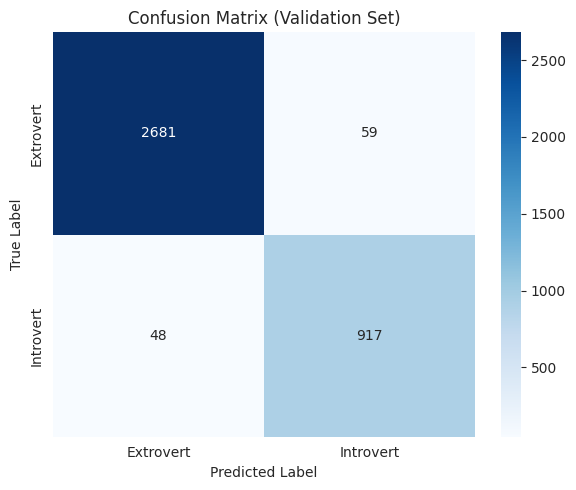

📈 ROC-AUC Score: 0.9720220490904278


In [113]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize model
model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

# Train on SMOTE-resampled training data
model.fit(X_train_resampled, y_train_resampled)

# Predict on validation set
y_pred = model.predict(X_val)
y_proba = model.predict_proba(X_val)[:, 1]

# Evaluation
print("📊 Classification Report:\n", classification_report(y_val, y_pred))

# Confusion Matrix with Seaborn
cm = confusion_matrix(y_val, y_pred)
labels = ['Extrovert', 'Introvert']

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Validation Set)')
plt.tight_layout()
plt.show()

# ROC-AUC Score
print("📈 ROC-AUC Score:", roc_auc_score(y_val, y_proba))


The model was rigorously evaluated using a validation set that was held out from the original training data. 

- 20% of the training data was separated before applying SMOTE to ensure an unbiased assessment of model performance. The validation results demonstrated strong predictive power, with:
    - An accuracy of 97%, an F1-score of 0.94 for the minority class (Introvert), and a ROC-AUC score of 0.97. 
  
  These metrics indicate that the model generalizes well to unseen data, and thus it was deemed reliable for generating predictions on the final test dataset provided by the competition.

In [114]:
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import pandas as pd

# Step 1: Separate features and target
X_full = df_train.drop('Personality', axis=1)
y_full = df_train['Personality']  # Already label encoded: 0 = Extrovert, 1 = Introvert

# Step 2: Apply SMOTE to full training data
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_full, y_full)

# Step 3: Retrain model on SMOTE-balanced data
final_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
final_model.fit(X_resampled, y_resampled)

# Step 4: Predict on df_test
y_test_pred = final_model.predict(df_test)

# Step 5: Map predicted labels back to original classes
label_map = {0: "Extrovert", 1: "Introvert"}
predicted_labels = [label_map[pred] for pred in y_test_pred]

# Step 6: Extract exact original IDs and cast to integer (no float formatting)
test_file = pd.read_csv('test.csv')
original_ids = test_file['id'].astype(int)  # 🔥 Force IDs to int, removes .0 issue

# Step 7: Create submission DataFrame with correct labels
submission = pd.DataFrame({
    'id': original_ids,
    'Personality': predicted_labels
})

# Step 8: Save submission file
submission.to_csv('personality_predictions.csv', index=False)
print("✅ Submission file 'personality_predictions.csv' saved with correct integer Ids.")


✅ Submission file 'personality_predictions.csv' saved with correct integer Ids.
